<a href="https://colab.research.google.com/github/chavan1807chinmayi-create/CSL701-CE03_Machine-Learning-Lab/blob/main/CE03_ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name**: **Chinmayi Milind Chavan**

**Roll No.: CE03**

**Batch : CE1**

**Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [4]:
# Task 1: Load and Understand the Dataset

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Column names
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# Load the dataset
df = pd.read_csv("diabetes.csv",
                 header=0) # Use the first row as header
df.columns = columns # Assign the desired column names

# 1. Print first 5 records
print("First 5 records:")
print(df.head())

# 2. Print dataset shape
print("\nDataset shape:")
print(df.shape)

# 3. Print data types
print("\nData types:")
print(df.dtypes)

# 4. Print descriptive statistics
print("\nDescriptive statistics:")
print(df.describe())

First 5 records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset shape:
(768, 9)

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    floa

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Number of Non-Diabetic cases: 500
Number of Diabetic cases: 268

Percentage of Non-Diabetic cases: 65.1 :
Percentage of Diabetic cases: 34.9 :


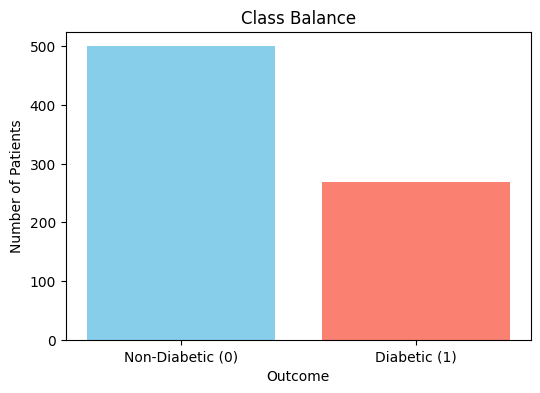

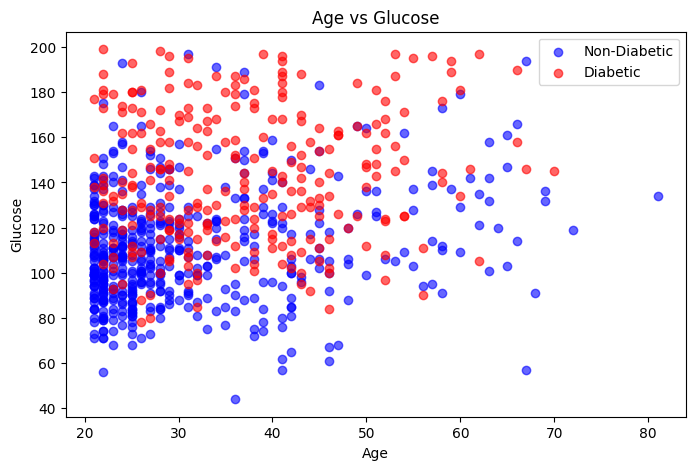

In [6]:
# Task 2: Exploratory Data Analysis (EDA)
import pandas as pd
import matplotlib.pyplot as plt
# Load the dataset
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv("diabetes.csv",
                 header=0) # Use the first row as header
df.columns = columns # Assign the desired column names

# 1. Count diabetic and non-diabetic cases
count = df["Outcome"].value_counts()

print("Number of Non-Diabetic cases:", count[0])
print("Number of Diabetic cases:", count[1])

# 2. Calculate percentage
percentage = df["Outcome"].value_counts(normalize=True) * 100

print("\nPercentage of Non-Diabetic cases:", round(percentage[0], 2), ":")
print("Percentage of Diabetic cases:", round(percentage[1], 2), ":")

# 3. Bar chart for class balance
plt.figure(figsize=(6, 4))

plt.bar(
    ["Non-Diabetic (0)", "Diabetic (1)"],
    [count[0], count[1]],
    color=["skyblue", "salmon"]
)

plt.title("Class Balance")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

# 4. Scatter plot: Age vs Glucose
plt.figure(figsize=(8, 5))

# Non-diabetic patients
plt.scatter(
    df[df["Outcome"] == 0]["Age"],
    df[df["Outcome"] == 0]["Glucose"],
    color="blue",
    label="Non-Diabetic",
    alpha=0.6
)

# Diabetic patients
plt.scatter(
    df[df["Outcome"] == 1]["Age"],
    df[df["Outcome"] == 1]["Glucose"],
    color="red",
    label="Diabetic",
    alpha=0.6
)

plt.title("Age vs Glucose")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.legend()

plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [8]:
# Task 3: Preprocessing and Handling Missing Values
import numpy as np
import pandas as pd

# Load the dataset
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(
    "diabetes.csv",
    header=0 # Use the first row as header
)
df.columns = columns # Assign the desired column names

# 1. Features where 0 is physically impossible
invalid_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# 2. Replace 0 with NaN
df[invalid_features] = df[invalid_features].replace(0, np.nan)

# 3. Check missing values
print("Missing values after replacing 0 with NaN:")
print(df.isnull().sum())

# 4. Fill missing values using median
for column in invalid_features:
    df[column] = df[column].fillna(df[column].median())

# 5. Check again for missing values
print("\nMissing values after median imputation:")
print(df.isnull().sum())

# 6. Display the cleaned dataset
print("\nFirst 5 rows of cleaned dataset:")
print(df.head())

# 7. Check dataset shape
print("\nDataset shape:")
print(df.shape)

Missing values after replacing 0 with NaN:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

First 5 rows of cleaned dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89     

#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [11]:
# Task 4: Stratified Train-Test Splitting
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the cleaned dataset
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(
    "diabetes.csv",
    header=0 # Use the first row as header
)
df.columns = columns # Assign the desired column names

# 2. Handle invalid zero values
invalid_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace 0 with missing value
df[invalid_features] = df[invalid_features].replace(0, pd.NA)

# Fill missing values with median
for column in invalid_features:
    df[column] = df[column].fillna(df[column].median())

# 3. Separate X and y
# X = first 8 columns (features)
X = df.iloc[:, 0:8]

# y = 9th column (target)
y = df.iloc[:, 8]

# 4. Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    train_size=0.80,
    random_state=42,
    stratify=y
)

# 5. Display the sizes
print("Training data:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting data:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# 6. Check class proportions
print("\nClass distribution in original data:")
print(y.value_counts(normalize=True) * 100)

print("\nClass distribution in training data:")
print(y_train.value_counts(normalize=True) * 100)

print("\nClass distribution in testing data:")
print(y_test.value_counts(normalize=True) * 100)

Training data:
X_train shape: (614, 8)
y_train shape: (614,)

Testing data:
X_test shape: (154, 8)
y_test shape: (154,)

Class distribution in original data:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Class distribution in training data:
Outcome
0    65.14658
1    34.85342
Name: proportion, dtype: float64

Class distribution in testing data:
Outcome
0    64.935065
1    35.064935
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [19]:
# Task 5: Custom Bootstrap Sampling Function

def get_bootstrap_sample(X, y):
    """
    Generate a bootstrap sample using sampling with replacement.

    Parameters:
        X : Feature matrix
        y : Target vector

    Returns:
        X_bootstrap : Resampled feature matrix
        y_bootstrap : Resampled target vector
        indices     : Selected row indices
    """

    # Number of training samples
    N = len(X)

    # Randomly select N indices with replacement
    indices = np.random.choice(
        N,
        size=N,
        replace=True
    )

    # Create bootstrap samples
    X_bootstrap = X.iloc[indices]
    y_bootstrap = y.iloc[indices]

    return X_bootstrap, y_bootstrap, indices



# Generate one bootstrap sample
X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)

# Display sizes
print("Original training set size:", len(X_train))
print("Bootstrap X size:", len(X_bootstrap))
print("Bootstrap y size:", len(y_bootstrap))

print("\nBootstrap sample shape:")
print("X_bootstrap:", X_bootstrap.shape)
print("y_bootstrap:", y_bootstrap.shape)

# Find unique indices and their frequencies
unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

# Indices that appear more than once
duplicated_indices = unique_indices[counts > 1]

print("Number of unique samples:", len(unique_indices))
print("Number of duplicated indices:", len(duplicated_indices))

print("\nSome duplicated indices:")
print(duplicated_indices[:10])


# All possible indices in the training set
all_indices = set(range(len(X_train)))

# Indices selected in the bootstrap sample
selected_indices = set(bootstrap_indices)

# OOB indices = indices that were not selected
oob_indices = sorted(
    all_indices - selected_indices
)

print("Number of OOB samples:", len(oob_indices))

print("\nSome OOB indices:")
print(oob_indices[:10])

Original training set size: 614
Bootstrap X size: 614
Bootstrap y size: 614

Bootstrap sample shape:
X_bootstrap: (614, 8)
y_bootstrap: (614,)
Number of unique samples: 388
Number of duplicated indices: 166

Some duplicated indices:
[ 1  4  7 11 14 28 33 34 35 38]
Number of OOB samples: 226

Some OOB indices:
[0, 2, 3, 9, 12, 13, 17, 21, 22, 23]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [21]:
# TASK 6: GROWING THE ENSEMBLE OF BASE CLASSIFIERS
import numpy as np
from sklearn.tree import DecisionTreeClassifier

# Number of trees
B = 50

# Empty list to store all decision trees
ensemble = []

# Train 50 decision trees
for i in range(B):

    # Create a bootstrap sample
    X_bootstrap, y_bootstrap, _ = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create a fully grown decision tree
    tree = DecisionTreeClassifier(
        max_depth=None,
        random_state=i
    )

    # Train the tree
    tree.fit(
        X_bootstrap,
        y_bootstrap
    )

    # Add the trained tree to the ensemble
    ensemble.append(tree)

# Display result
print("Number of trees in the ensemble:", len(ensemble))


Number of trees in the ensemble: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [25]:
# TASK 7: MAJORITY VOTING FROM SCRATCH
import numpy as np

def custom_bagging_predict(ensemble, X_test):
    """
    Aggregates predictions from an ensemble of classifiers using majority voting.

    Args:
        ensemble (list): A list of trained classifier models.
        X_test (pd.DataFrame): The test feature matrix.

    Returns:
        np.array: Final predictions for X_test based on majority voting.
    """
    # Store predictions from all trees
    all_predictions = []

    # Get prediction from every tree
    for tree in ensemble:
        prediction = tree.predict(X_test)
        all_predictions.append(prediction)

    # Convert predictions into NumPy array
    all_predictions = np.array(all_predictions)

    # Store final predictions
    final_predictions = []

    # For every test sample
    for i in range(len(X_test)):

        # Get votes from all trees for the current sample
        votes = all_predictions[:, i]

        # Count votes for class 0 and class 1
        count_0 = np.sum(votes == 0)
        count_1 = np.sum(votes == 1)

        # Majority vote
        if count_1 > count_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


# Make predictions using the custom Bagging model
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

print("Bagging predictions: ")
print(y_pred_bagging)


# Number of test samples
num_test_samples = len(X_test)
print(f"Number of test samples: {num_test_samples}")

# Unique predicted classes from custom Bagging model
unique_predicted_classes = np.unique(y_pred_bagging)
print(f"Unique predicted classes (Custom Bagging): {unique_predicted_classes}")

Bagging predictions: 
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 1 1 0
 0 1 0 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0
 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 1
 0 0 0 0 1 0]
Number of test samples: 154
Unique predicted classes (Custom Bagging): [0 1]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

Single Decision Tree Confusion Matrix:
[[87 13]
 [16 38]]

Custom Bagging Confusion Matrix:
[[92  8]
 [ 9 45]]

PERFORMANCE COMPARISON

Single Decision Tree:
Accuracy : 0.8117
Precision: 0.7451
Recall   : 0.7037
F1-Score : 0.7238

Custom Bagging:
Accuracy : 0.8896
Precision: 0.8491
Recall   : 0.8333
F1-Score : 0.8411


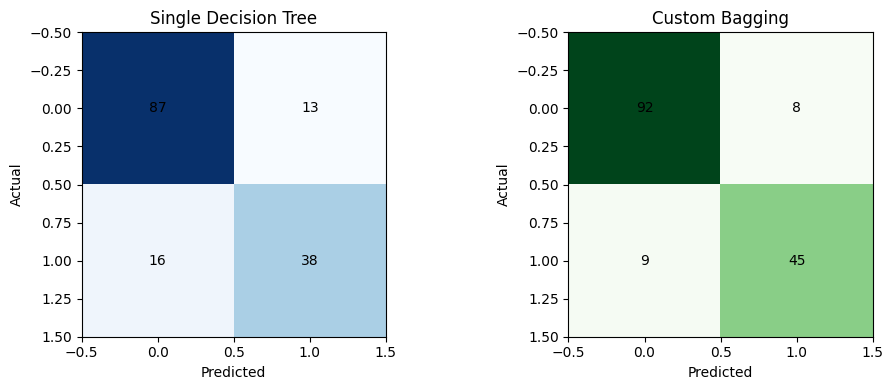

In [26]:
# TASK 8: SINGLE DECISION TREE VS BAGGING
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Single Decision Tree
single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# Train the single tree
single_tree.fit(X_train, y_train)

# Predict test data
y_pred_single = single_tree.predict(X_test)

# Confusion Matrices
cm_single = confusion_matrix(
    y_test,
    y_pred_single
)

cm_bagging = confusion_matrix(
    y_test,
    y_pred_bagging
)

print("Single Decision Tree Confusion Matrix:")
print(cm_single)

print("\nCustom Bagging Confusion Matrix:")
print(cm_bagging)

# Single Tree Metrics
accuracy_single = accuracy_score(
    y_test,
    y_pred_single
)

precision_single = precision_score(
    y_test,
    y_pred_single
)

recall_single = recall_score(
    y_test,
    y_pred_single
)

f1_single = f1_score(
    y_test,
    y_pred_single
)

# Bagging Metrics
accuracy_bagging = accuracy_score(
    y_test,
    y_pred_bagging
)

precision_bagging = precision_score(
    y_test,
    y_pred_bagging
)

recall_bagging = recall_score(
    y_test,
    y_pred_bagging
)

f1_bagging = f1_score(
    y_test,
    y_pred_bagging
)

# Print Results
print("\n==============================")
print("PERFORMANCE COMPARISON")
print("==============================")

print("\nSingle Decision Tree:")
print("Accuracy :", round(accuracy_single, 4))
print("Precision:", round(precision_single, 4))
print("Recall   :", round(recall_single, 4))
print("F1-Score :", round(f1_single, 4))

print("\nCustom Bagging:")
print("Accuracy :", round(accuracy_bagging, 4))
print("Precision:", round(precision_bagging, 4))
print("Recall   :", round(recall_bagging, 4))
print("F1-Score :", round(f1_bagging, 4))

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Single Tree
axes[0].imshow(cm_single, cmap="Blues")

axes[0].set_title("Single Decision Tree")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

for i in range(2):
    for j in range(2):
        axes[0].text(
            j,
            i,
            cm_single[i, j],
            ha="center",
            va="center"
        )


# Bagging
axes[1].imshow(cm_bagging, cmap="Greens")

axes[1].set_title("Custom Bagging")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

for i in range(2):
    for j in range(2):
        axes[1].text(
            j,
            i,
            cm_bagging[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

Single Decision Tree AUC: 0.7869
Custom Bagging AUC: 0.9553


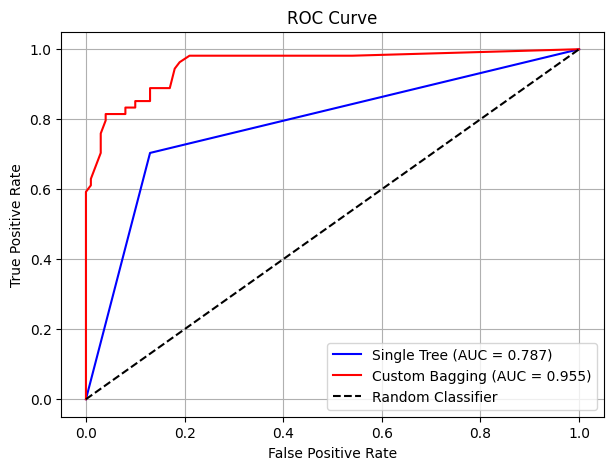

In [27]:
# TASK 9: ROC-AUC ANALYSIS
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Single Decision Tree Probability
single_probability = single_tree.predict_proba(
    X_test
)[:, 1]

# Bagging Probability
all_probabilities = []

# Get probability from every tree
for tree in ensemble:

    probability = tree.predict_proba(
        X_test
    )[:, 1]

    all_probabilities.append(probability)

# Convert to NumPy array
all_probabilities = np.array(
    all_probabilities
)

# Average probabilities of all 50 trees
bagging_probability = np.mean(
    all_probabilities,
    axis=0
)

# Calculate AUC
auc_single = roc_auc_score(
    y_test,
    single_probability
)
auc_bagging = roc_auc_score(
    y_test,
    bagging_probability
)
print("Single Decision Tree AUC:",
      round(auc_single, 4))

print("Custom Bagging AUC:",
      round(auc_bagging, 4))

# Create ROC Curves
fpr_single, tpr_single, _ = roc_curve(
    y_test,
    single_probability
)

fpr_bagging, tpr_bagging, _ = roc_curve(
    y_test,
    bagging_probability
)

# Plot ROC Curves
plt.figure(figsize=(7, 5))

plt.plot(
    fpr_single,
    tpr_single,
    color="blue",
    label="Single Tree (AUC = {:.3f})".format(auc_single)
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    color="red",
    label="Custom Bagging (AUC = {:.3f})".format(auc_bagging)
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()
plt.grid()

plt.show()


#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

Scikit-Learn Bagging Accuracy:
0.8831

Scikit-Learn Bagging Confusion Matrix:
[[91  9]
 [ 9 45]]


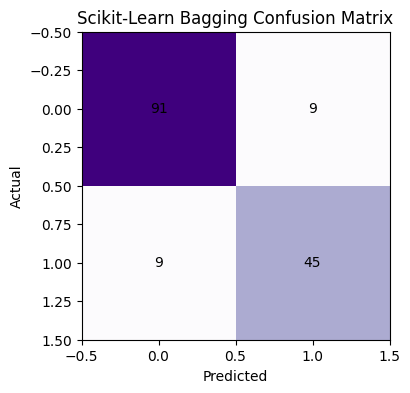


FINAL ACCURACY COMPARISON
Single Decision Tree: 0.8117
Custom Bagging: 0.8896
Scikit-Learn Bagging: 0.8831


In [30]:
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Create the base Decision Tree
base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# Create Scikit-Learn Bagging Classifier
bagging_model = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    random_state=42
)

# Train the Bagging Classifier
bagging_model.fit(
    X_train,
    y_train
)

# Make predictions
y_pred_sklearn = bagging_model.predict(
    X_test
)

# Calculate accuracy
accuracy_sklearn = accuracy_score(
    y_test,
    y_pred_sklearn
)

# Confusion Matrix
cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)

# Display Results
print("Scikit-Learn Bagging Accuracy:")
print(round(accuracy_sklearn, 4))
print("\nScikit-Learn Bagging Confusion Matrix:")
print(cm_sklearn)

# Plot Confusion Matrix for Scikit-Learn Bagging
plt.figure(figsize=(5, 4))
plt.imshow(cm_sklearn, cmap="Purples")
plt.title("Scikit-Learn Bagging Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_sklearn[i, j],
            ha="center",
            va="center"
        )
plt.show()

# Compare All Models
print("\n==============================")
print("FINAL ACCURACY COMPARISON")
print("==============================")
print(
    "Single Decision Tree:",
    round(accuracy_single, 4)
)
print(
    "Custom Bagging:",
    round(accuracy_bagging, 4)
)
print(
    "Scikit-Learn Bagging:",
    round(accuracy_sklearn, 4)
)


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?